In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
class ReLU:
    def forward(self, x):
        self.x = x
        return np.maximum(0, x)
    def backward(self, grad):
        loc_grad = (self.x>0).astype(float)
        return grad*loc_grad

class Sigmoid:
    def forward(self, x):
        self.x = x
        return 1/(1+np.exp(-x))
    def backward(self, grad):
        sigma = 1/(1+np.exp(-self.x))
        return grad*(sigma*(1-sigma))

class Tanh:
    def forward(self, x):
        self.x = x
        return np.tanh(self.x)
    def backward(self, grad):
        loc_grad = 1 - (np.tanh(self.x)**2)
        return grad*loc_grad

class MSE:
    def forward_loss(self, y0, y):
        return np.mean((y-y0)**2)
    def back_loss(self, y0, y):
        return (-2*(y-y0))/len(y)

class BCE:
    def forward_loss(self, x, y):
        ep = 1e-16
        return -np.mean((y * np.log(x+ep))+((1-y)*np.log(ep+1-x)))
    def back_loss(self, x, y):
        ep = 1e-16
        return ((x-y)/((x+ep)*(1-x+ep)))/len(y)

class Dense:
    def __init__(self, input_size, output_size):
        self.w = np.random.rand(input_size, output_size)*0.001
        self.b = np.zeros((1, output_size))
        self.mw = np.zeros_like(self.w)
        self.mb = np.zeros_like(self.b)
        self.vw = np.zeros_like(self.w)
        self.vb = np.zeros_like(self.b)
    def forward(self, x):
        self.x = x
        y0 = (self.x@self.w)+self.b
        return y0
    def backward(self, dl_dy0):
        self.m = len(self.x)
        self.dl_dw = (self.x.T@dl_dy0)/self.m
        self.dl_db = np.sum(dl_dy0, axis = 0, keepdims=True)/self.m
        self.dl_dx = (dl_dy0@self.w.T)
        return self.dl_dx
    def SGD_ADAM_step(self, lr = 0.01, alpha = 0.9, beta = 0.99, epsilon = 1e-8, t = 1):
        self.mw = (alpha*self.mw)+((1-alpha)*self.dl_dw)
        self.mb = (alpha*self.mb)+((1-alpha)*self.dl_db)
        self.vw = (beta*self.vw)+((1-beta)*(self.dl_dw**2))
        self.vb = (beta*self.vb)+((1-beta)*(self.dl_db**2))

        mw_hat = self.mw/(1-alpha**t)
        mb_hat = self.mb/(1-alpha**t)
        vw_hat = self.vw /(1-beta**t)
        vb_hat = self.vb/(1-beta**t)

        self.w = self.w - lr * (mw_hat/(np.sqrt(vw_hat)+epsilon))
        self.b = self.b - lr * (mb_hat/(np.sqrt(vb_hat)+epsilon))

In [25]:
def deep_neural_net(x, y, batch_size = 256, epochs = 1_000_000):
    layer1 = Dense (2, 128)
    act1 = ReLU()
    layer2 = Dense(128, 256)
    act2 = Tanh()
    layer3 = Dense(256, 512)
    act3 = ReLU()
    layer4 = Dense(512, 8)
    act4 = Sigmoid()
    loss_fun = MSE()
    history = []
    total_samples = x.shape[0]
    for t in range(epochs):
        indices = np.random.choice(total_samples, size=batch_size, replace=False)
        xi = x[indices]
        yi = y[indices]

        z1 = layer1.forward(xi)
        a1 = act1.forward(z1)
        z2 = layer2.forward(a1)
        a2 = act2.forward(z2)
        z3 = layer3.forward(a2)
        a3 = act3.forward(z3)
        z4 = layer4.forward(a3)
        a4 = act4.forward(z4)
        loss = loss_fun.forward_loss(a4, yi)
        if t % 500 == 0:
            history.append(loss)

        grad = loss_fun.back_loss(a4, yi)
        grad = act4.backward(grad)
        grad = layer4.backward(grad)
        grad = act3.backward(grad)
        grad = layer3.backward(grad)
        grad = act2.backward(grad)
        grad = layer2.backward(grad)
        grad = act1.backward(grad)
        grad = layer1.backward(grad)

        layer1.SGD_ADAM_step(t = t+1)
        layer2.SGD_ADAM_step(t = t+1)
        layer3.SGD_ADAM_step(t =t+1)
        layer4.SGD_ADAM_step(t= t+1)
    return history, [layer1, act1, layer2, act2, layer3, act3, layer4, act4, loss_fun]

In [ ]:
N = 100_000
x = np.random.randn(N,2)
y = np.zeros((N,8))

y[:,0] = (x[:,0] + x[:,1] > 0)
y[:,1] = (x[:,0] - x[:,1] > 0)
y[:,2] = (x[:,0] > 0)
y[:,3] = (x[:,1] > 0)
y[:,4] = (x[:,0]**2 + x[:,1]**2 > 1)
y[:,5] = (np.sin(x[:,0]) > 0)
y[:,6] = (np.cos(x[:,1]) > 0)
y[:,7] = (x[:,0]*x[:,1] > 0)
y = y.astype(float)
split = int(0.8 * len(x))
x_train = x[:split]
y_train = y[:split]
x_test = x[split:]
y_test = y[split:]

/tmp/ipykernel_320249/446144474.py:12: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
/tmp/ipykernel_320249/446144474.py:14: RuntimeWarning: overflow encountered in exp
  sigma = 1/(1+np.exp(-self.x))


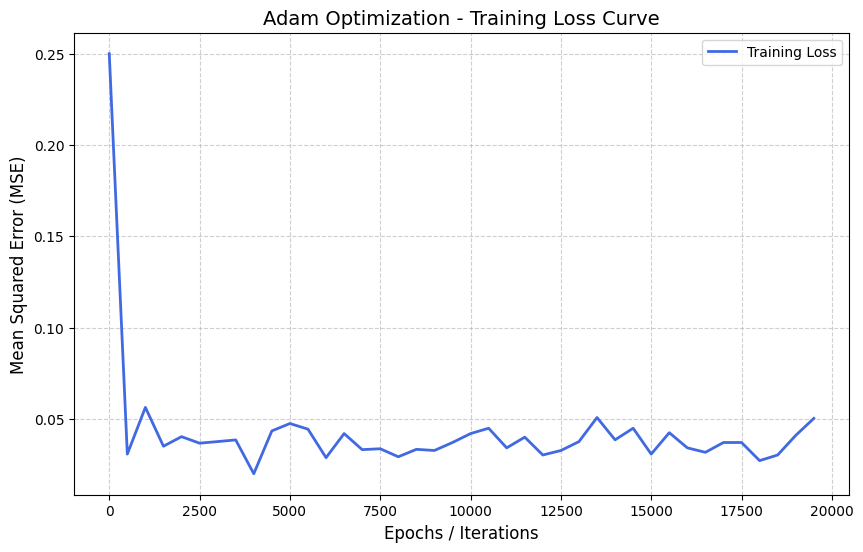

Evaluation Results:
Final Training Loss: 0.050293
Test Set Loss:       0.035143
Overall Test Accuracy:  96.48%

Accuracy breakdown per logical operation:
 - x0 + x1 > 0            : 98.18%
 - x0 - x1 > 0            : 97.12%
 - x0 > 0                 : 99.19%
 - x1 > 0                 : 99.54%
 - Circle (r>1)           : 91.90%
 - sin(x0) > 0            : 98.90%
 - cos(x1) > 0            : 88.55%
 - XOR-like (x0*x1 > 0)   : 98.50%


In [30]:
history, model_layers = deep_neural_net(x_train, y_train, batch_size=256, epochs=20000)
plt.figure(figsize=(10, 6))
iterations = [i * 500 for i in range(len(history))]
plt.plot(iterations, history, label='Training Loss', color='royalblue', linewidth=2)
plt.title('Adam Optimization - Training Loss Curve', fontsize=14)
plt.xlabel('Epochs / Iterations', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

[layer1, act1, layer2, act2, layer3, act3, layer4, act4, loss_fun] = model_layers
z1 = layer1.forward(x_test)
a1 = act1.forward(z1)
z2 = layer2.forward(a1)
a2 = act2.forward(z2)
z3 = layer3.forward(a2)
a3 = act3.forward(z3)
z4 = layer4.forward(a3)
predictions = act4.forward(z4)
test_loss = loss_fun.forward_loss(predictions, y_test)
binary_predictions = (predictions > 0.5).astype(float)
accuracy = np.mean(binary_predictions == y_test) * 100

print("Evaluation Results:")
print(f"Final Training Loss: {history[-1]:.6f}")
print(f"Test Set Loss:       {test_loss:.6f}")
print(f"Overall Test Accuracy:  {accuracy:.2f}%")
print("\nAccuracy breakdown per logical operation:")
labels = [
    "x0 + x1 > 0", "x0 - x1 > 0", "x0 > 0", "x1 > 0",
    "Circle (r>1)", "sin(x0) > 0", "cos(x1) > 0", "XOR-like (x0*x1 > 0)"
]
for i, label in enumerate(labels):
    task_acc = np.mean(binary_predictions[:, i] == y_test[:, i]) * 100
    print(f" - {label:<22} : {task_acc:.2f}%")